In [1]:
!pip install -q nltk vaderSentiment spacy torch tqdm
!python -m spacy download fr_core_news_sm  # Français
!python -m spacy download en_core_web_sm  # Anglais

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 51.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 85.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
import json
import os
import nltk
import torch
import spacy
import multiprocessing
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from nltk.util import ngrams
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# ==========================
# 1️⃣ Chargement des Données
# ==========================
comments_path = "/kaggle/input/comments-posts-ooredoo-djezzy-mobilis/Comments_clean.csv"
output_dir = "/kaggle/working/"

# Charger le DataFrame
comments_df = pd.read_csv(comments_path)

# Chemin du fichier Excel
lexicon_xlsx_path = "/kaggle/input/comments-posts-ooredoo-djezzy-mobilis/Costum_lexicon.xlsx"
lexicon_csv_path = "/kaggle/working/Custom_lexicon.csv"  # Sauvegarde en CSV

# Conversion de XLSX en CSV
df_lexicon = pd.read_excel(lexicon_xlsx_path)
df_lexicon.to_csv(lexicon_csv_path, index=False)

print(f"✅ Conversion terminée : {lexicon_csv_path}")

# Vérifier les colonnes
if "Sentiments" not in comments_df.columns:
    raise ValueError("La colonne 'Sentiments' est absente du fichier CSV.")

✅ Conversion terminée : /kaggle/working/Custom_lexicon.csv


In [4]:
# ==============================
# 2️⃣ Chargement des Modèles NLP
# ==============================
nltk.download("punkt")
nlp_fr = spacy.load("fr_core_news_sm")  # Modèle français
nlp_en = spacy.load("en_core_web_sm")   # Modèle anglais

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [5]:
# ==========================================
# 3️⃣ Personnalisation de VADER avec bigrams
# ==========================================

# Charger le lexique personnalisé
custom_lexicon = {}
for _, row in df_lexicon.iterrows():
    word, score = row[0], row[1]  # Suppose que la 1ère colonne est le mot et la 2ème le score
    custom_lexicon[word] = float(score)

print("✅ Lexique personnalisé chargé avec succès !")

# Générer les bigrams et les ajouter au lexique
bigram_lexicon = {}
for phrase in custom_lexicon.keys():
    tokens = phrase.split()  # Séparer en mots
    if len(tokens) > 1:  # Si c'est un bigramme
        bigram_lexicon["_".join(tokens)] = custom_lexicon[phrase]  # Ajouter au lexique sous forme "mot1_mot2"

# Fusionner les deux lexiques
custom_lexicon.update(bigram_lexicon)

# Initialiser VADER avec le lexique personnalisé
analyzer = SentimentIntensityAnalyzer()
analyzer.lexicon.update(custom_lexicon)

✅ Lexique personnalisé chargé avec succès !


<ipython-input-5-f52cfe8b8b88>:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  word, score = row[0], row[1]  # Suppose que la 1ère colonne est le mot et la 2ème le score


In [6]:
!pip install arabic-reshaper
!pip install python-bidi

In [7]:
# =================================================
# 4️⃣ Fonction de Tokenization (inclut les bigrams)
# =================================================
def tokenize_text(text, lang="fr"):
    """Tokenisation en mots et en bigrammes pour capturer le contexte."""
    if lang == "fr":
        doc = nlp_fr(text)
    else:
        doc = nlp_en(text)
    
    tokens = [token.text.lower() for token in doc if not token.is_punct]
    bigrams = ["_".join(bigram) for bigram in ngrams(tokens, 2)]  # Convertir les bigrams en format "mot1_mot2"
    
    return tokens + bigrams

print("✅ Lexique mis à jour avec les bigrammes !")

✅ Lexique mis à jour avec les bigrammes !


In [8]:
# ====================================
# 5️⃣ Fonction d'Annotation avec VADER
# ====================================
def analyze_sentiment(comment):
    """Analyse le sentiment d'un commentaire avec VADER en tenant compte des bigrams."""
    if not isinstance(comment, str) or comment.strip() == "":
        return "Neutre"

    tokens = tokenize_text(comment)  # Tokenisation en mots et bigrams
    modified_comment = " ".join(tokens)  # Reconstruire la phrase avec bigrams
    
    scores = analyzer.polarity_scores(modified_comment)
    if scores["compound"] >= 0.05:
        return "Positif"
    elif scores["compound"] <= -0.05:
        return "Negatif"
    else:
        return "Neutre"

In [9]:
# ===============================================
# 6️⃣ Exécution en Parallèle avec CUDA (si dispo)
# ===============================================
def process_comments_parallel(df):
    """Exécute l'annotation en parallèle avec multiprocessing ou CUDA."""
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Utilisation de {device} pour le traitement.")

    with multiprocessing.Pool(processes=os.cpu_count()) as pool:
        sentiments = list(tqdm(pool.imap(analyze_sentiment, df["Comments"]), total=len(df)))
    
    df["Predicted_Sentiment"] = sentiments
    return df

In [10]:
# =========================
# 7️⃣ Application du Modèle
# =========================
print("🔄 Annotation des sentiments...")
comments_df = process_comments_parallel(comments_df)

🔄 Annotation des sentiments...
Utilisation de cuda pour le traitement.


100%|██████████| 3644/3644 [00:10<00:00, 346.67it/s]


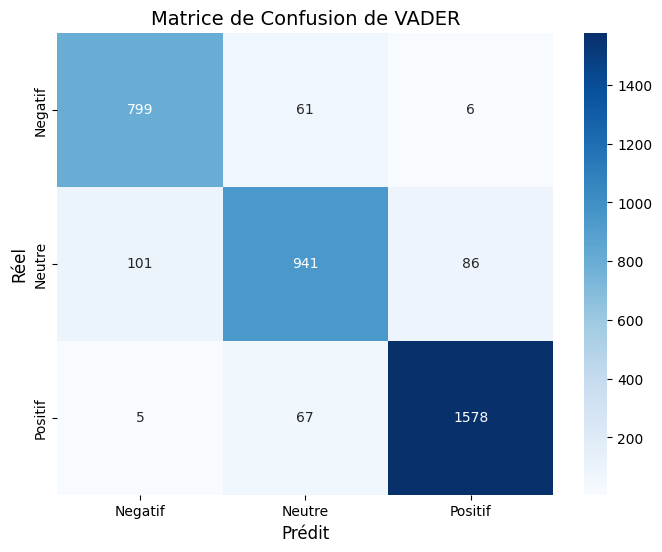

✅ Matrice de confusion enregistrée dans : /kaggle/working/confusion_matrix.png


<Figure size 640x480 with 0 Axes>

In [11]:
# ==============================
# 8️⃣ Évaluation des Résultats
# ==============================
y_true = comments_df["Sentiments"]
y_pred = comments_df["Predicted_Sentiment"]

# Calcul des métriques
accuracy = accuracy_score(y_true, y_pred) * 100  # Pourcentage
precision = precision_score(y_true, y_pred, average=None) * 100
recall = recall_score(y_true, y_pred, average=None) * 100

# Générer la matrice de confusion
labels = ["Negatif", "Neutre", "Positif"]
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Tracer la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)

# Titres et labels
plt.title("Matrice de Confusion de VADER", fontsize=14)
plt.xlabel("Prédit", fontsize=12)
plt.ylabel("Réel", fontsize=12)
plt.show()

# Sauvegarde de la Matrice
confusion_matrix_path = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(confusion_matrix_path)
print(f"✅ Matrice de confusion enregistrée dans : {confusion_matrix_path}")

In [12]:
# Affichage des résultats
print(f"\n✅ Accuracy du modèle sur l'ensemble de test : {round(accuracy, 2)} %\n")
report = classification_report(y_true, y_pred)
print(report)


✅ Accuracy du modèle sur l'ensemble de test : 91.05 %

              precision    recall  f1-score   support

     Negatif       0.88      0.92      0.90       866
      Neutre       0.88      0.83      0.86      1128
     Positif       0.94      0.96      0.95      1650

    accuracy                           0.91      3644
   macro avg       0.90      0.90      0.90      3644
weighted avg       0.91      0.91      0.91      3644



In [13]:
# ================================
# 9️⃣ Enregistrement des Résultats
# ================================
metrics_path = os.path.join(output_dir, "metrics_results.txt")
annotated_csv_path = os.path.join(output_dir, "Annotated_Comments.csv")

with open(metrics_path, "w") as f:
    f.write(f"🔍 Évaluation des Sentiments\n")
    f.write("=" * 50 + "\n")
    f.write(f"\n✅ Accuracy du modèle sur l'ensemble de test : {round(accuracy, 2)} %\n\n")
    f.write(report)

# Sauvegarde du DataFrame annoté
comments_df.to_csv(annotated_csv_path, index=False)

print(f"\n✅ Annotation terminée ! Résultats enregistrés dans : {annotated_csv_path}")
print(f"✅ Scores des métriques enregistrés dans : {metrics_path}")


✅ Annotation terminée ! Résultats enregistrés dans : /kaggle/working/Annotated_Comments.csv
✅ Scores des métriques enregistrés dans : /kaggle/working/metrics_results.txt


In [14]:
# ======================================
#  1️⃣0️⃣ Sauvegarde du Modèle (Lexique)
# ======================================

vader_lexicon_path = os.path.join(output_dir, "vader_custom_lexicon.json")

# Sauvegarde du lexique dans un fichier JSON
with open(vader_lexicon_path, "w", encoding="utf-8") as f:
    json.dump(custom_lexicon, f, ensure_ascii=False, indent=4)

print(f"✅ Lexique personnalisé sauvegardé : {vader_lexicon_path}")

✅ Lexique personnalisé sauvegardé : /kaggle/working/vader_custom_lexicon.json
